# Text classification with an RNN, early stopping, dropout, and an ablation study

This notebook builds a sentence level classifier with a recurrent neural network, specifically, a GRU. The goal is to see how a classical RNN pipeline is constructed end to end, and how training stability and generalization depend on regularization and stopping criteria.

We will:

- Load a real text classification dataset
- Build a word level vocabulary and dataloaders
- Implement a GRU based classifier
- Train with dropout and early stopping
- Run an ablation study that changes only the dropout rate
- Inspect 5 to 10 new errors and interpret what the model is doing

The dataset used here is Yelp Polarity from the Hugging Face Datasets library. It is a binary classification task where labels indicate positive or negative reviews.

We subsample the dataset so that training is fast enough for a tutorial setting. The code is written so that you can increase the sample sizes later to get stronger performance.


In [ ]:
# If you run this in a fresh environment, install dependencies.
# In many course environments, most of these are already installed.

# !pip install torch datasets tqdm matplotlib scikit-learn pandas

## Imports and reproducibility

In [ ]:
import re
import random
from collections import Counter
from dataclasses import dataclass
from pandas import DataFrame


import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report


def set_seed(seed: int = 13) -> None:
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(13)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Load the dataset

We use Yelp Polarity, which contains many reviews. When initially experimenting, it is often helpful to have quick runs and experiment on subsamples first to ensure everything works as intended. Then, later in the pipeline you can increase to the full dataset if needed.

We create three splits:

- train for gradient updates
- validation for early stopping and model selection
- test for a final report after all choices are fixed

The validation split is created from the original training split.


In [ ]:
raw = load_dataset("yelp_polarity")

raw["train"], raw["test"]

(Dataset({
     features: ['text', 'label'],
     num_rows: 560000
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 38000
 }))

It is often useful to first look at an example.

In [ ]:
for i in range(5):
    print(f"Example {i}:\n{raw['train'][i]}\n")

Example 0:
{'text': "Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.", 'label': 0}

Example 1:
{'text': "Been going to Dr. Goldberg for over 10 years. I think I was one of his 1st patients when he started at MHMG. He's been great over the years and is really all about the big picture. It is because of him, not my now former gyn Dr. Markoff, that I found out I have fibroids. He explores all options wit

In [ ]:
# Subsample for speed. You can increase these if you want stronger results.
N_TRAIN = 5000
N_VAL = 1000
N_TEST = 1000

train_full = raw["train"].shuffle(seed=13)  # We only shuffle the training set.
test_full = raw["test"].shuffle(seed=13)

train_ds_hf = train_full.select(range(N_TRAIN + N_VAL))
test_ds_hf = test_full.select(range(N_TEST))

val_ds_hf = train_ds_hf.select(range(N_TRAIN, N_TRAIN + N_VAL))
train_ds_hf = train_ds_hf.select(range(N_TRAIN))

print(
    f"Dataset lengths: train={len(train_ds_hf)}, val={len(val_ds_hf)}, test={len(test_ds_hf)}"
)

Dataset lengths: train=5000, val=1000, test=1000


## Tokenization and vocabulary

To keep the pipeline transparent, we use a simple word tokenizer based on regular expressions. This is not state of the art tokenization, but it makes it easy to reason about what the model sees. In practice, one oftens uses more advanced tokenizers.

The vocabulary is built from the training data only. This matters because using validation or test text to build the vocabulary leaks information into training.

We use special tokens:
- <pad> for padding inside batches
- <unk> for words that are not in the vocabulary


In [ ]:
TOKEN_RE = re.compile(r"[A-Za-z0-9']+")


def tokenize(text: str):
    return TOKEN_RE.findall(text.lower())


PAD = "<pad>"
UNK = "<unk>"


def build_vocab(texts, min_freq: int = 2, max_size: int = 30000) -> dict:
    """
    Build a vocabulary mapping from tokens to integer indices.
    The vocabulary will include only tokens that appear at least `min_freq` times,
    and will be limited to `max_size` tokens (including PAD and UNK).
    """
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))
    # Reserve 0 for PAD and 1 for UNK.
    vocab = {PAD: 0, UNK: 1}
    for word, freq in counter.most_common():
        if freq < min_freq:
            break
        if len(vocab) >= max_size:
            break
        vocab[word] = len(vocab)
    return vocab


vocab = build_vocab(train_ds_hf["text"], min_freq=2, max_size=30000)
vocab_size = len(vocab)
vocab_size, list(vocab.items())[:10]

(12978,
 [('<pad>', 0),
  ('<unk>', 1),
  ('the', 2),
  ('and', 3),
  ('i', 4),
  ('to', 5),
  ('a', 6),
  ('was', 7),
  ('of', 8),
  ('it', 9)])

In [ ]:
def numericalize(tokens: list, vocab: dict) -> list:
    """
    Convert a list of tokens into a list of integer indices using the provided vocabulary.
    Tokens not found in the vocabulary will be mapped to the index of UNK.
    """
    return [vocab.get(tok, vocab[UNK]) for tok in tokens]


# Sanity check
sample = train_ds_hf[0]["text"]
tokenize(sample)[:20], numericalize(tokenize(sample)[:20], vocab)[:20]

(['i',
  'have',
  'found',
  'my',
  'last',
  'meal',
  'nmy',
  'wife',
  'and',
  'i',
  'first',
  'came',
  'to',
  'love',
  'bouchon',
  'in',
  '2009',
  'while',
  'staying',
  'at'],
 [4,
  24,
  283,
  15,
  180,
  212,
  484,
  412,
  3,
  4,
  107,
  101,
  5,
  137,
  3498,
  11,
  4557,
  164,
  912,
  26])

## Dataset and collate function

We first define some custom classes and Dataset classes that are required for the proper running of the classification pipeline.


In [ ]:
@dataclass
class Batch:
    x: torch.Tensor  # (B, T) token ids
    lengths: torch.Tensor  # (B,) true lengths
    y: torch.Tensor  # (B,) labels


class TextDataset(Dataset):
    def __init__(self, hf_ds: dict, vocab: dict, max_len: int = 200) -> None:
        self.ds = hf_ds
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.ds)

    def __getitem__(self, idx: int) -> tuple:
        """Given an index, return the token ids and label for the corresponding sample."""
        item = self.ds[idx]
        tokens = tokenize(item["text"])

        # Convert to ids and truncate
        if len(tokens) == 0:
            ids = [self.vocab[UNK]]
        else:
            ids = numericalize(tokens, self.vocab)[: self.max_len]
            if len(ids) == 0:
                ids = [self.vocab[UNK]]

        label = int(item["label"])  # 0 negative, 1 positive
        return ids, label


def collate(batch: list) -> Batch:
    """Collate function to convert a list of samples into a batch."""
    # batch: list of (ids_list, label)
    lengths = torch.tensor([len(x) for x, _ in batch], dtype=torch.long)
    max_len = int(lengths.max().item()) if len(batch) > 0 else 0
    x = torch.full((len(batch), max_len), vocab[PAD], dtype=torch.long)
    y = torch.tensor([y for _, y in batch], dtype=torch.long)
    for i, (ids, _) in enumerate(batch):
        x[i, : len(ids)] = torch.tensor(ids, dtype=torch.long)
    return Batch(x=x, lengths=lengths, y=y)

We represent each example as a sequence of token ids. However, we need to truncate very long reviews and pad the rest to form batches (so that they are of uniform size) as RNNs expect sequences in a batch to have the same length.

The idea is to pad shorter examples up to the longest example in the batch. Very long reviews can dominate memory and runtime, so we also cap the maximum length and truncate beyond it.

We can plot the distribution of lengths in the training dataset to get an understanding of what is a reasonable max length.

We also keep the true sequence length, which is useful for masking and for selecting the correct hidden state when sequences have different lengths.

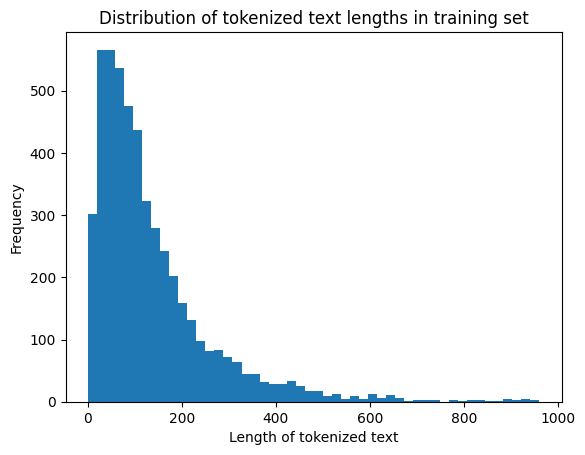

In [ ]:
# Plot distribution of lengths in the training set
lengths = [len(tokenize(text)) for text in train_ds_hf["text"]]
plt.hist(lengths, bins=50)
plt.title("Distribution of tokenized text lengths in training set")
plt.xlabel("Length of tokenized text")
plt.ylabel("Frequency")
plt.show()

We choose the maximum length after inspecting the distribution above. Unfortunately, there is always a tradeoff:
 - larger MAX_LEN keeps more context but increases compute and padding waste
 - smaller MAX_LEN is faster but may drop important information for long reviews

For this tutorial, we will set MAX_LEN to 200, but of course, you can change it and compare the results. Note that training and the embedding size below will take significantly more time. A common practical choice is to set MAX_LEN around a high percentile, for example p90 or p95.

In terms of batch size, people often choose values that are powers of 2 (2, 4, 16, etc.). Smaller batch size generally leads to noisier gradients, but higher batch size requires more memory (RAM/VRAM on a GPU). Again, there is always a tradeoff and one chooses based on their goals and capabilities.

In [ ]:
MAX_LEN = 200
BATCH_SIZE = 64

print(f"Using MAX_LEN={MAX_LEN} and BATCH_SIZE={BATCH_SIZE}")

train_ds = TextDataset(train_ds_hf, vocab, max_len=MAX_LEN)
val_ds = TextDataset(val_ds_hf, vocab, max_len=MAX_LEN)
test_ds = TextDataset(test_ds_hf, vocab, max_len=MAX_LEN)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate
)

batch0 = next(iter(train_loader))
print("One batch shapes")
print(
    "x:",
    tuple(batch0.x.shape),
    "lengths:",
    tuple(batch0.lengths.shape),
    "y:",
    tuple(batch0.y.shape),
)
print("Example lengths:", batch0.lengths[:10].tolist())

Using MAX_LEN=200 and BATCH_SIZE=64
One batch shapes
x: (64, 200) lengths: (64,) y: (64,)
Example lengths: [171, 200, 200, 185, 200, 55, 200, 58, 124, 200]


## Model: GRU classifier with dropout

We implement a GRU based text classifier.

Architecture:
- embedding layer that maps token ids to vectors
- dropout on embeddings to regularize the input representation
- multi layer GRU encoder
- dropout on the final representation
- linear layer to two logits

We represent each sequence by the final hidden state of the GRU. This is a standard baseline choice. Other choices include attention over all time steps or pooling over time.

We picked some default hyperparameters for you. In general, hyperparameter tuning (learning rate, embedding size, number of layers, layer width, and so on) has to be done in this phase (train on the train set, and choose based on the best performance on the validation set). However, it is often useful to use an external hyperparameter manager, or at least have them all in the same place so that changing them is easier.


In [ ]:
class GRUClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 32,
        hidden_dim: int = 32,
        num_layers: int = 2,
        dropout: float = 0.3,
        pad_idx: int = 0,
        num_classes: int = 2,
    ) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_dropout = nn.Dropout(dropout)
        # GRU dropout applies between layers when num_layers > 1.
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.rep_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        # x: (B, T)
        emb = self.emb_dropout(self.embedding(x))  # (B, T, E)
        # Pack for efficiency and to avoid wasting computation on padding.
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, h_n = self.gru(packed)  # h_n: (num_layers, B, H)
        h_last = h_n[-1]  # (B, H)
        rep = self.rep_dropout(h_last)
        logits = self.fc(rep)
        return logits


model = GRUClassifier(vocab_size=vocab_size, dropout=0.3).to(device)
model

GRUClassifier(
  (embedding): Embedding(12978, 32, padding_idx=0)
  (emb_dropout): Dropout(p=0.3, inplace=False)
  (gru): GRU(32, 32, num_layers=2, batch_first=True, dropout=0.3)
  (rep_dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)

## Training utilities

We train with:
- cross entropy loss
- Adam optimizer
- early stopping on validation loss

Early stopping stops training when validation loss has not improved for a number of epochs. We also restore the best model parameters observed during training.


In [ ]:
def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    """Evaluate the model on the given data loader and return metrics."""
    model.eval()
    all_y = []
    all_pred = []
    all_prob = []
    total_loss = 0.0
    n = 0
    loss_fn = nn.CrossEntropyLoss()
    with torch.no_grad():
        for batch in loader:
            x = batch.x.to(device)
            lengths = batch.lengths.to(device)
            y = batch.y.to(device)

            logits = model(x, lengths)
            loss = loss_fn(logits, y)
            total_loss += float(loss.item()) * y.size(0)
            n += y.size(0)

            probs = torch.softmax(logits, dim=-1)
            pred = probs.argmax(dim=-1)

            all_y.append(y.cpu().numpy())
            all_pred.append(pred.cpu().numpy())
            all_prob.append(probs.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    probs = np.concatenate(all_prob)
    avg_loss = total_loss / max(n, 1)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return {
        "loss": avg_loss,
        "acc": acc,
        "f1": f1,
        "y_true": y_true,
        "y_pred": y_pred,
        "probs": probs,
    }


def train_one_epoch(
    model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer
) -> dict:
    """Train for one epoch and return average loss and accuracy."""
    model.train()
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0.0
    n = 0
    correct = 0

    for batch in loader:
        x = batch.x.to(device)
        lengths = batch.lengths.to(device)
        y = batch.y.to(device)

        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = loss_fn(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += float(loss.item()) * y.size(0)
        n += y.size(0)
        pred = logits.argmax(dim=-1)
        correct += int((pred == y).sum().item())

    return {"loss": total_loss / max(n, 1), "acc": correct / max(n, 1)}


def fit_with_early_stopping(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    lr: float = 1e-3,
    max_epochs: int = 20,
    patience: int = 3,
) -> list:
    """
    Train with early stopping on validation loss.

    We track the best validation loss seen so far. If it does not improve for `patience`
    consecutive epochs, we stop training and restore the best model parameters.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_state = None
    best_val = float("inf")
    best_epoch = None
    bad_epochs = 0

    history = []
    print("Training with early stopping on validation loss")
    print(f"max_epochs={max_epochs}, patience={patience}, lr={lr}")
    print(
        f"{'epoch':>5}  {'train_loss':>10}  {'train_acc':>9}  {'val_loss':>8}  {'val_acc':>7}  {'note':>18}"
    )
    print("-" * 70)

    for epoch in range(1, max_epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer)
        val_metrics = evaluate(model, val_loader)

        improved = val_metrics["loss"] < best_val - 1e-4
        if improved:
            best_val = val_metrics["loss"]
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }
            bad_epochs = 0
            note = "new best val_loss"
        else:
            bad_epochs += 1
            note = f"no improve ({bad_epochs}/{patience})"

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_acc": train_metrics["acc"],
                "val_loss": val_metrics["loss"],
                "val_acc": val_metrics["acc"],
                "val_f1": val_metrics["f1"],
            }
        )

        print(
            f"{epoch:5d}  {train_metrics['loss']:10.4f}  {train_metrics['acc']:9.4f}  "
            f"{val_metrics['loss']:8.4f}  {val_metrics['acc']:7.4f}  {note:>18}"
        )

        if bad_epochs >= patience:
            print()
            print(
                f"Early stopping triggered at epoch {epoch} because validation loss did not improve "
                f"for {patience} consecutive epochs."
            )
            print(f"Best validation loss was {best_val:.4f} at epoch {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(
            f"Restored model parameters from epoch {best_epoch} (best val_loss={best_val:.4f})."
        )

    return history

## Baseline training run

This run uses dropout 0.3 and early stopping based on the validation split.


In [ ]:
set_seed(13)

MAX_EPOCHS = 20
PATIENCE = 3
LEARNING_RATE = 1e-3

model_base = GRUClassifier(vocab_size=vocab_size, dropout=0.3).to(device)
hist_base = fit_with_early_stopping(
    model_base,
    train_loader,
    val_loader,
    lr=LEARNING_RATE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
)


base_val = evaluate(model_base, val_loader)
base_test = evaluate(model_base, test_loader)

Training with early stopping on validation loss
max_epochs=20, patience=3, lr=0.001
epoch  train_loss  train_acc  val_loss  val_acc                note
----------------------------------------------------------------------
    1      0.6935     0.5070    0.6904   0.5270   new best val_loss
    2      0.6812     0.5664    0.6631   0.5780   new best val_loss
    3      0.6359     0.6364    0.6104   0.6670   new best val_loss
    4      0.5765     0.7028    0.6212   0.6560    no improve (1/3)
    5      0.5168     0.7502    0.4960   0.7720   new best val_loss
    6      0.4649     0.7828    0.4748   0.7850   new best val_loss
    7      0.4252     0.8116    0.4201   0.8120   new best val_loss
    8      0.3988     0.8246    0.4270   0.8230    no improve (1/3)
    9      0.3551     0.8482    0.4014   0.8190   new best val_loss
   10      0.3292     0.8606    0.3962   0.8330   new best val_loss
   11      0.3219     0.8660    0.5207   0.8070    no improve (1/3)
   12      0.3019     0.8766 

It is often useful to look at the learning curve of the model. We can do so by plotting the whole history of training and comparing with the validation setup. The best model notion, however, is a matter of choice. That is, sometimes minimizing validation loss and maximizing validation accuracy can yield different best models.

Best val loss at epoch 10: 0.3962
Last trained epoch (early stop epoch if it stopped early): 13


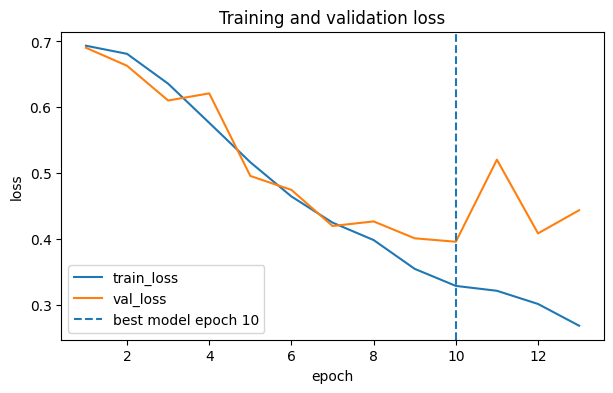

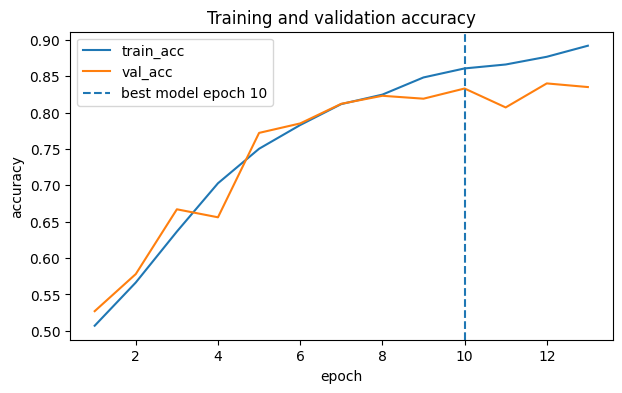

In [ ]:
epochs = np.array([h["epoch"] for h in hist_base])
train_loss = np.array([h["train_loss"] for h in hist_base])
val_loss = np.array([h["val_loss"] for h in hist_base])
train_acc = np.array([h["train_acc"] for h in hist_base])
val_acc = np.array([h["val_acc"] for h in hist_base])

best_i = int(np.argmin(val_loss))
best_epoch = int(epochs[best_i])

# Early stopping epoch is simply the last epoch that ran
early_stop_epoch = int(epochs[-1])

print(f"Best val loss at epoch {best_epoch}: {val_loss[best_i]:.4f}")
print(f"Last trained epoch (early stop epoch if it stopped early): {early_stop_epoch}")

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_loss, label="train_loss")
plt.plot(epochs, val_loss, label="val_loss")
plt.axvline(best_epoch, linestyle="--", label=f"best model epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_acc, label="train_acc")
plt.plot(epochs, val_acc, label="val_acc")
plt.axvline(best_epoch, linestyle="--", label=f"best model epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

## Test report

We report accuracy and macro F1, and also show a classification report.


In [ ]:
print("Validation: acc", base_val["acc"], "macro_f1", base_val["f1"])
print("Test:       acc", base_test["acc"], "macro_f1", base_test["f1"])
print()
print(classification_report(base_test["y_true"], base_test["y_pred"], digits=4))

Validation: acc 0.833 macro_f1 0.8329396912285335
Test:       acc 0.843 macro_f1 0.8429646670500863

              precision    recall  f1-score   support

           0     0.8445    0.8462    0.8453       507
           1     0.8415    0.8398    0.8406       493

    accuracy                         0.8430      1000
   macro avg     0.8430    0.8430    0.8430      1000
weighted avg     0.8430    0.8430    0.8430      1000



## Ablation study: dropout

An ablation study changes one component while keeping everything else fixed. This helps you attribute differences in performance to a specific design choice.

Here we keep the data, optimizer, learning rate, model size, and early stopping the same, and change only the dropout rate. This isolates the effect of regularization.

We train three models:
- dropout 0.0
- dropout 0.3 (we already have this one)
- dropout 0.5

Moreover, note that the above code was did not define a separate function for running the experiment, which is generally bad practice. Below we define a ``run_experiment`` function so that we can reuse it.

In [ ]:
def run_experiment(dropout: float, seed: int = 13) -> tuple:
    set_seed(seed)
    model = GRUClassifier(vocab_size=vocab_size, dropout=dropout).to(device)
    _ = fit_with_early_stopping(
        model,
        train_loader,
        val_loader,
        lr=LEARNING_RATE,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
    )
    val = evaluate(model, val_loader)
    test = evaluate(model, test_loader)
    return model, val, test


model_d0, val_d0, test_d0 = run_experiment(dropout=0.0, seed=13)
model_d5, val_d5, test_d5 = run_experiment(dropout=0.5, seed=13)

results = [
    ("dropout 0.0", val_d0["acc"], val_d0["f1"], test_d0["acc"], test_d0["f1"]),
    ("dropout 0.3", base_val["acc"], base_val["f1"], base_test["acc"], base_test["f1"]),
    ("dropout 0.5", val_d5["acc"], val_d5["f1"], test_d5["acc"], test_d5["f1"]),
]
results

Training with early stopping on validation loss
max_epochs=20, patience=3, lr=0.001
epoch  train_loss  train_acc  val_loss  val_acc                note
----------------------------------------------------------------------
    1      0.6888     0.5450    0.6796   0.5660   new best val_loss
    2      0.6328     0.6426    0.5820   0.6920   new best val_loss
    3      0.5224     0.7474    0.5088   0.7520   new best val_loss
    4      0.4246     0.8122    0.4553   0.7920   new best val_loss
    5      0.3488     0.8558    0.4281   0.8060   new best val_loss
    6      0.2879     0.8846    0.4161   0.8110   new best val_loss
    7      0.2484     0.9068    0.4325   0.8260    no improve (1/3)
    8      0.2025     0.9306    0.4338   0.8210    no improve (2/3)
    9      0.1756     0.9392    0.4942   0.8190    no improve (3/3)

Early stopping triggered at epoch 9 because validation loss did not improve for 3 consecutive epochs.
Best validation loss was 0.4161 at epoch 6.
Restored model par

[('dropout 0.0', 0.811, 0.8100958664200257, 0.812, 0.8118072906656416),
 ('dropout 0.3', 0.833, 0.8329396912285335, 0.843, 0.8429646670500863),
 ('dropout 0.5', 0.793, 0.7914212675742697, 0.817, 0.8147171297557202)]

In [ ]:
df = DataFrame(results, columns=["setting", "val_acc", "val_f1", "test_acc", "test_f1"])
df = df.sort_values(by=["val_f1", "val_acc"], ascending=False).reset_index(drop=True)

print("Ablation results, sorted by validation macro F1")
display(df)

Ablation results, sorted by validation macro F1


,setting,val_acc,val_f1,test_acc,test_f1
0,dropout 0.3,0.833,0.832940,0.843,0.842965
1,dropout 0.0,0.811,0.810096,0.812,0.811807
2,dropout 0.5,0.793,0.791421,0.817,0.814717


### Interpreting the ablation

You should interpret the results in terms of bias and variance.

- If dropout 0.0 does well on training but worse on validation, it suggests overfitting. However, the effect of overfitting is not as pronounced here as early stopping effecively is a form of regularization as well. Try running the pipeline without early stopping and compare these results again.
- Note that together with early stopping, dropout of 0.5 might hurt both validation and test, and therefore suggests underfitting.
- If an intermediate dropout does best, it suggests a useful regularization strength for this model and data size.

Because we subsampled the dataset, overfitting is plausible. With more training data, you might see dropout matter less.


## Error analysis

We inspect new errors from the best model among the three settings. We focus on confident mistakes, because they often reveal systematic issues such as sarcasm, negation, or mixed sentiment.

We will print 5 to 10 misclassified reviews with:
- predicted label and confidence
- true label
- a short text snippet


In [ ]:
def pick_best_model(models_and_metrics):
    # Choose by validation macro F1, break ties by validation loss.
    best = None
    for name, model, val in models_and_metrics:
        score = val["f1"]
        loss = val["loss"]
        if (
            best is None
            or score > best["score"] + 1e-8
            or (abs(score - best["score"]) <= 1e-8 and loss < best["loss"])
        ):
            best = {"name": name, "model": model, "score": score, "loss": loss}
    return best


candidates = [
    ("dropout 0.0", model_d0, val_d0),
    ("dropout 0.3", model_base, base_val),
    ("dropout 0.5", model_d5, val_d5),
]
best = pick_best_model(candidates)
best["name"], best["score"], best["loss"]

('dropout 0.3', 0.8329396912285335, 0.39621183252334596)

In [ ]:
best_model = best["model"]
test_eval = evaluate(best_model, test_loader)

y_true = test_eval["y_true"]
y_pred = test_eval["y_pred"]
probs = test_eval["probs"]

wrong = np.where(y_true != y_pred)[0]
len(wrong), len(y_true)

(157, 1000)

In [ ]:
# Get confidence for the predicted class
pred_conf = probs[np.arange(len(y_pred)), y_pred]
wrong_conf = pred_conf[wrong]

# Sort wrong examples by confidence descending
top_wrong_idx = wrong[np.argsort(-wrong_conf)]


def label_name(y):
    return "positive" if int(y) == 1 else "negative"


def show_errors(hf_ds, indices, k: int = 8, max_chars: int = 400):
    shown = 0
    for i in indices:
        if shown >= k:
            break
        item = hf_ds[int(i)]
        text = item["text"].replace("\n", " ").strip()
        yt = int(item["label"])
        yp = int(y_pred[int(i)])
        conf = float(pred_conf[int(i)])

        print("=" * 90)
        print(f"index: {int(i)}")
        print(f"true label:      {label_name(yt)}")
        print(f"predicted label: {label_name(yp)}")
        print(f"predicted probability:      {conf:.3f}")
        print()
        print(text[:max_chars] + ("..." if len(text) > max_chars else ""))
        print()
        shown += 1


show_errors(test_ds_hf, top_wrong_idx, k=8)

index: 520
true label:      negative
predicted label: positive
predicted probability:      0.989

I was excited to try this place, so much I left it for last on my list of Scottsdale yelp discoveries. Looking at their description and reviews I was under the impression that Mabel's would be a down right awesome cocktail bar. It also came highly recommended by the great folks at Kaz. \n\nWalking in the decor spoke of prohibition and the menu showed pics of barrels aging and flapper women a...err...

index: 378
true label:      positive
predicted label: negative
predicted probability:      0.988

Honestly, I'm a little surprised that Destihl's Yelp rating isn't higher. \n\nTwo of my friends and I wandered in on a weekday night while looking for a place to eat at in downtown Champaign. The restaurant was relatively full for 7pm on Thursday, so I'd imagine there may be a wait on weekend nights. \n\nBeers = good. I think we tried 4? The strawberry blonde ale on tap was a clear favorite for u

### Interpreting the errors

Use the printed examples to identify patterns. Common patterns in review sentiment classification include:

- Starting with words related to "high expectation" but changing tone after, or vice versa.
- Mixed sentiment where the review contains both praise and complaints
- Negation scope where a positive word appears inside a negative construction
- Sarcasm and understatement
- Domain specific language where a neutral technical issue is associated with negative sentiment
- Label noise where the human label is arguably wrong or ambiguous

Write your interpretation after looking at the examples that your run prints, because the exact errors depend on the random shuffle and on the model setting selected by validation performance.


## Optional extension

If you want to explore further:
- Increase MAX_LEN to include more context for long reviews
- Switch to a bidirectional GRU and compare results
- Replace the simple tokenizer with a subword tokenizer and compare error types

All of these changes should be evaluated with the same early stopping setup and compared by a controlled ablation. Feel free to play around with the hyperparameter values as well, and the effect of early stopping.
